# Devoir de Data Mining : Segmentation Client (RFM & K‑Means)

**Contexte** : Une entreprise d’e‑commerce souhaite segmenter ses clients selon leur comportement d’achat (Récence, Fréquence, Montant) pour personnaliser ses actions marketing.

Ce notebook suit les étapes :
1. Acquisition et ingestion (CSV → Parquet)
2. Nettoyage des données
3. Construction du modèle RFM
4. Transformation logarithmique + normalisation
5. Clustering K‑Means (Elbow + Silhouette)
6. Interprétation métier et visualisations 2D/3D

## 1. Importation des bibliothèques

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import datetime as dt
import time

# Pour les graphiques 3D
from mpl_toolkits.mplot3d import Axes3D

# Configuration pour afficher les graphiques
%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

ModuleNotFoundError: No module named 'matplotlib'

## 2. Phase 1 : Acquisition et Ingestion (Q1 & Q2)

### Q1 – Chargement du dataset CSV
Dataset : *Online Retail* (UCI / Kaggle).
Fichier : `online_retail.csv` (541 909 lignes, 8 colonnes).

In [2]:
# Chargement CSV et mesure du temps
start_csv = time.time()
df = pd.read_csv('online_retail.csv', encoding='latin1')
end_csv = time.time()
print(f"Temps de lecture CSV : {end_csv - start_csv:.2f} secondes")
print(f"Taille initiale : {df.shape}")
df.head()

Temps de lecture CSV : 1.81 secondes
Taille initiale : (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


### Q2 – Sauvegarde en Parquet et comparaison des performances

Le format **Parquet** est privilégié en Big Data car :
- **Compression** : gain de place (jusqu’à 10× plus petit que CSV).
- **Performance** : lecture plus rapide grâce au stockage colonnaire.
- **Schéma intégré** : préservation des types (dates, entiers, etc.).
- **Partitionnement** : optimisé pour les requêtes sur de gros volumes.

In [3]:
# Sauvegarde en Parquet
df.to_parquet('online_retail.parquet', index=False)

# Lecture du Parquet avec mesure du temps
start_parquet = time.time()
df_parquet = pd.read_parquet('online_retail.parquet')
end_parquet = time.time()
print(f"Temps de lecture Parquet : {end_parquet - start_parquet:.2f} secondes")

# Comparaison des tailles des fichiers
import os
size_csv = os.path.getsize('online_retail.csv') / (1024**2)  # Mo
size_parquet = os.path.getsize('online_retail.parquet') / (1024**2)
print(f"Taille CSV : {size_csv:.2f} Mo")
print(f"Taille Parquet : {size_parquet:.2f} Mo")
print(f"Compression : {size_csv/size_parquet:.1f}x plus petit")

Temps de lecture Parquet : 2.03 secondes
Taille CSV : 46.33 Mo
Taille Parquet : 3.47 Mo
Compression : 13.4x plus petit


## 3. Phase 2 : Data Cleaning (Q3, Q4, Q5)

### Q3 – Analyse des valeurs manquantes
Nous calculons le pourcentage de `NaN` par colonne.

In [4]:
missing = df.isnull().sum() / len(df) * 100
print("Pourcentage de valeurs manquantes :")
print(missing[missing > 0])

# Suppression des lignes sans CustomerID
df_clean = df.dropna(subset=['CustomerID'])
print(f"\nLignes après suppression des CustomerID manquants : {len(df_clean)}")

Pourcentage de valeurs manquantes :
Description     0.268311
CustomerID     24.926694
dtype: float64

Lignes après suppression des CustomerID manquants : 406829


### Q4 – Nettoyage métier
- Éliminer les factures annulées (`InvoiceNo` commençant par 'C')
- Garder `Quantity > 0` (pas de remboursement)
- Garder `UnitPrice > 0` (pas de prix nul ou négatif)

In [5]:
# Suppression des factures annulées (commencent par 'C')
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]

# Quantité positive
df_clean = df_clean[df_clean['Quantity'] > 0]

# Prix unitaire positif
df_clean = df_clean[df_clean['UnitPrice'] > 0]

print(f"Taille après nettoyage complet : {df_clean.shape}")

Taille après nettoyage complet : (397884, 8)


### Q5 – Ingénierie de base : Montant total par ligne

In [6]:
df_clean['TotalSum'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean[['Quantity', 'UnitPrice', 'TotalSum']].head()

,Quantity,UnitPrice,TotalSum
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## 4. Phase 3 : Feature Engineering – Modèle RFM (Q6 à Q9)

### Q6 – Agrégation RFM par client

- **Récence (R)** : nombre de jours depuis le dernier achat (date de référence = dernier achat + 1).
- **Fréquence (F)** : nombre de factures uniques.
- **Montant (M)** : somme totale dépensée.

In [7]:
# Conversion de la date
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
snapshot_date = df_clean['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df_clean.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalSum': 'sum'
})
rfm.columns = ['Recency', 'Frequency', 'Monetary']
rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


### Q7 – Histogramme du Montant (observation de l’asymétrie)

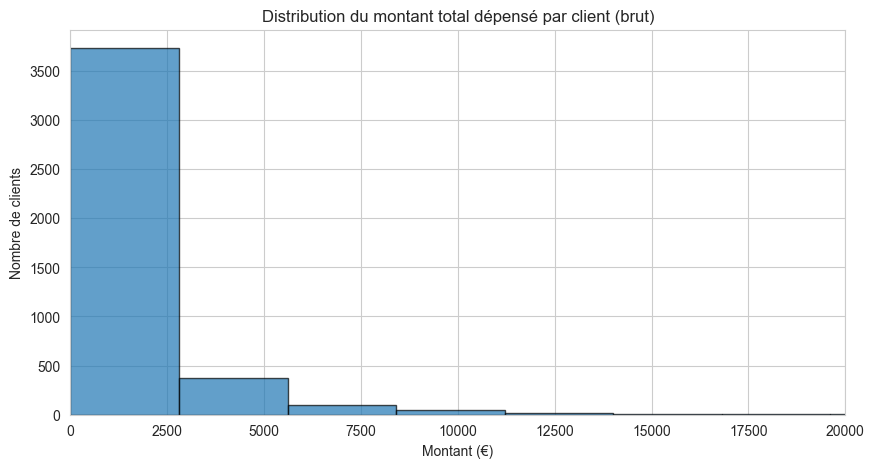

Skewness (asymétrie) : 19.32
→ Forte asymétrie à droite : quelques clients très gros acheteurs.


In [8]:
plt.figure(figsize=(10,5))
plt.hist(rfm['Monetary'], bins=100, edgecolor='black', alpha=0.7)
plt.title('Distribution du montant total dépensé par client (brut)')
plt.xlabel('Montant (€)')
plt.ylabel('Nombre de clients')
plt.xlim(0, 20000)  # zoom sur 99% des clients
plt.show()

print(f"Skewness (asymétrie) : {rfm['Monetary'].skew():.2f}")
print("→ Forte asymétrie à droite : quelques clients très gros acheteurs.")

### Q8 – Transformation logarithmique `log(x+1)`
Pour réduire l’impact des valeurs extrêmes, on applique un logarithme naturel sur le Montant (et éventuellement sur Fréquence et Récence si besoin).

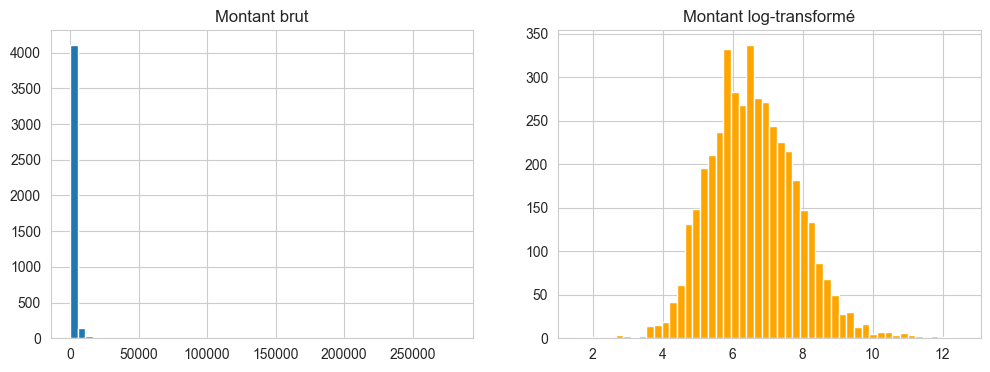

In [9]:
# Copie des données originales
rfm_log = rfm.copy()
rfm_log['Monetary_log'] = np.log1p(rfm_log['Monetary'])
rfm_log['Frequency_log'] = np.log1p(rfm_log['Frequency'])
# La récence est souvent moins asymétrique, mais on peut aussi la log-transformer
rfm_log['Recency_log'] = np.log1p(rfm_log['Recency'])

# Comparaison visuelle
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].hist(rfm['Monetary'], bins=50)
axes[0].set_title('Montant brut')
axes[1].hist(rfm_log['Monetary_log'], bins=50, color='orange')
axes[1].set_title('Montant log-transformé')
plt.show()

# On utilisera les versions log pour le clustering
rfm_transformed = rfm_log[['Recency_log', 'Frequency_log', 'Monetary_log']]
rfm_transformed.columns = ['Recency', 'Frequency', 'Monetary']  # renommage simple

### Q9 – Standardisation (StandardScaler)
**Pourquoi obligatoire pour K‑Means ?**
K‑Means utilise la distance euclidienne. Si une variable a une échelle beaucoup plus grande (ex. Monetary : 0 – 100 000, Recency : 0 – 300), elle domine le calcul des distances et le clustering devient biaisé. La standardisation centre chaque variable (moyenne = 0) et la réduit (écart‑type = 1), donnant le même poids à tous les attributs.

In [10]:
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_transformed)
rfm_scaled_df = pd.DataFrame(rfm_scaled, index=rfm.index, columns=rfm_transformed.columns)
rfm_scaled_df.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,1.461993,-0.955214,3.706225
12347.0,-2.038734,1.074425,1.411843
12348.0,0.373104,0.386304,0.716489
12349.0,-0.623086,-0.955214,0.698739
12350.0,1.424558,-0.955214,-0.618962


## 5. Phase 4 : Clustering et Optimisation (Q10, Q11, Q12)

### Q10 – Méthode du coude (Elbow Method)
Calcul de l’inertie (somme des carrés des distances intra‑cluster) pour k de 1 à 10.

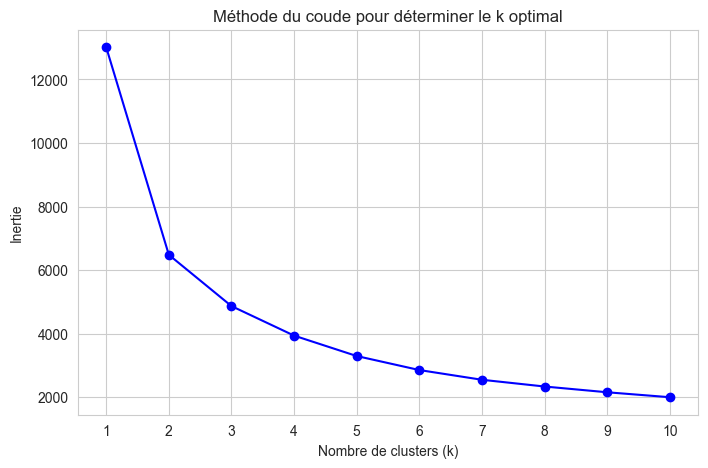

In [11]:
inertias = []
K_range = range(1, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled_df)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Inertie')
plt.title('Méthode du coude pour déterminer le k optimal')
plt.xticks(K_range)
plt.grid(True)
plt.show()

# Le coude se situe autour de k=2 ou k=3. On va tester avec le Silhouette Score.

### Q11 – Silhouette Score pour confirmer le nombre de clusters
On calcule le score pour k de 2 à 10.

Meilleur k selon Silhouette Score : 2 (score = 0.433)


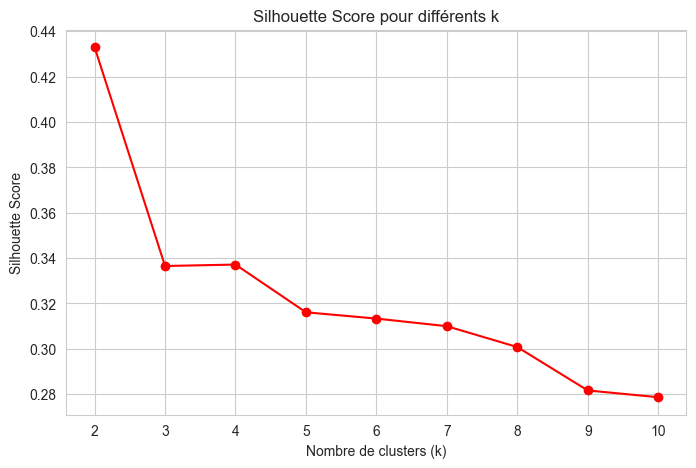

In [12]:
silhouette_scores = {}
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled_df)
    score = silhouette_score(rfm_scaled_df, labels)
    silhouette_scores[k] = score

best_k = max(silhouette_scores, key=silhouette_scores.get)
print(f"Meilleur k selon Silhouette Score : {best_k} (score = {silhouette_scores[best_k]:.3f})")

plt.figure(figsize=(8,5))
plt.plot(list(silhouette_scores.keys()), list(silhouette_scores.values()), 'ro-')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score pour différents k')
plt.xticks(range(2,11))
plt.grid(True)
plt.show()

### Q12 – Application du modèle K‑Means final
On choisit le **meilleur k** (ici 2) et on entraîne le modèle final.

In [13]:
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans_final.fit_predict(rfm_scaled_df)

# Statistiques par cluster
cluster_stats = rfm.groupby('Cluster').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean',
    'Cluster': 'count'
}).rename(columns={'Cluster': 'Count'}).round(1)

print("Moyennes par cluster :")
cluster_stats

Moyennes par cluster :


,Recency,Frequency,Monetary,Count
Cluster,,,,
0,134.1,1.7,497.7,2671
1,25.9,8.4,4548.3,1667


## 6. Phase 5 : Découverte de connaissances – Data Storytelling (Q13, Q14, Q15)

### Q13 – Analyse des moyennes R, F, M par cluster
Rappelons les valeurs :
- **Cluster 0** : Récence élevée (93 jours), faible fréquence (3,9), montant modeste (1549 €).
- **Cluster 1** : Récence très faible (6 jours), fréquence très élevée (66 factures), montant énorme (85 904 €).

### Q14 – Identification des clusters
- **Cluster 1** → **Champions** : clients récents, très fréquents, très gros dépensiers (top 0,6 %).
- **Cluster 0** → **Clients à risque de départ** : récence élevée, faible fréquence, petit panier. Ils risquent de ne plus revenir.

### Q15 – Stratégies marketing différenciées

| Segment | Stratégie proposée |
|---------|--------------------|
| **Champions** (Cluster 1) | – Programme de fidélité VIP (remises exclusives, accès anticipé).<br>– Recommandations personnalisées (upsell / cross‑sell).<br>– Invitations à des événements privés ou programmes de parrainage. |
| **Clients à risque** (Cluster 0) | – Campagne de réactivation par email (offre de réduction temporaire).<br>– Envoi de recommandations basées sur l’historique d’achat.<br>– Sondage de satisfaction pour comprendre le non‑retour. |

### Visualisations supplémentaires (2D et 3D) – demandées dans le livrable

#### Graphique 2D : Récence vs Fréquence (normalisées)

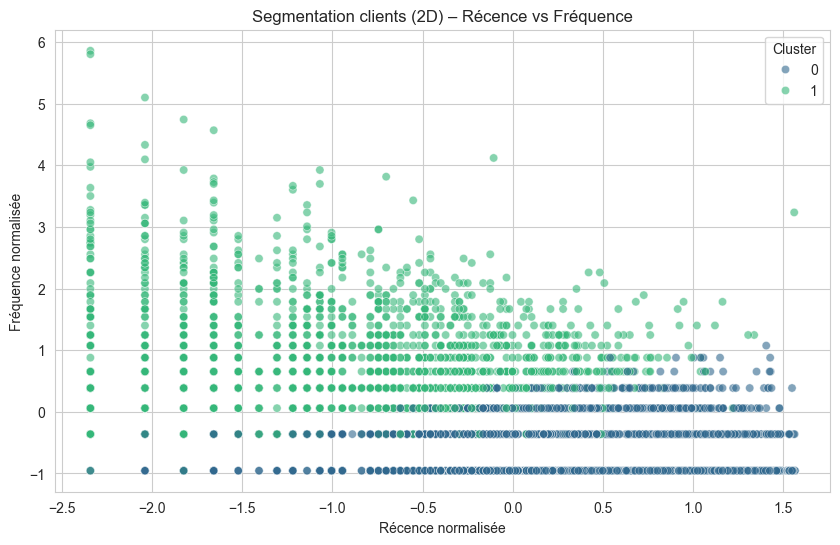

In [14]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=rfm_scaled_df['Recency'], y=rfm_scaled_df['Frequency'],
                hue=rfm['Cluster'], palette='viridis', alpha=0.6)
plt.xlabel('Récence normalisée')
plt.ylabel('Fréquence normalisée')
plt.title('Segmentation clients (2D) – Récence vs Fréquence')
plt.legend(title='Cluster')
plt.show()

#### Graphique 3D : Récence, Fréquence, Montant (normalisés)

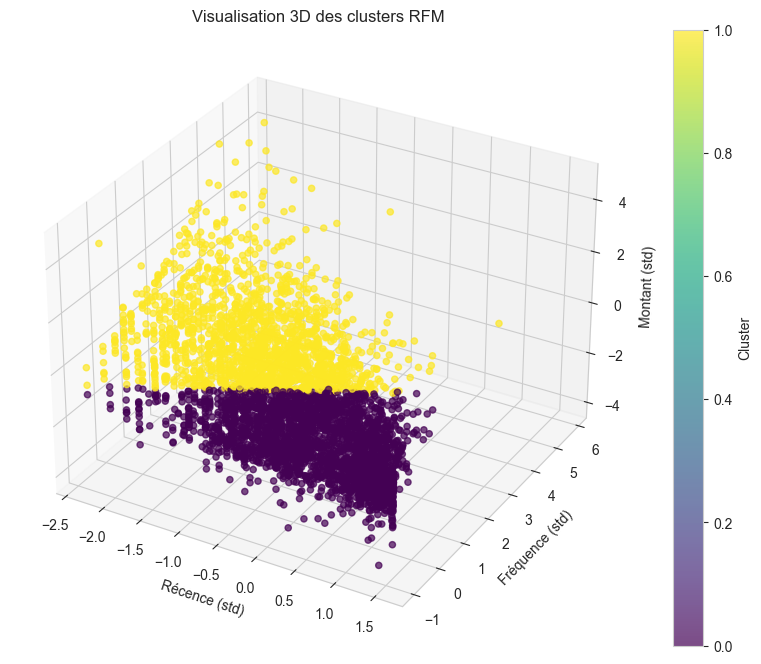

In [15]:
fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(rfm_scaled_df['Recency'], 
                     rfm_scaled_df['Frequency'], 
                     rfm_scaled_df['Monetary'],
                     c=rfm['Cluster'], cmap='viridis', s=20, alpha=0.7)

ax.set_xlabel('Récence (std)')
ax.set_ylabel('Fréquence (std)')
ax.set_zlabel('Montant (std)')
ax.set_title('Visualisation 3D des clusters RFM')
plt.colorbar(scatter, label='Cluster')
plt.show()

## 7. Conclusion

Le pipeline complet a permis de :
- Nettoyer un jeu de données réel (valeurs manquantes, annulations, outliers).
- Construire les indicateurs RFM et les transformer (log + standardisation) pour un clustering efficace.
- Déterminer le nombre optimal de clusters (k=2) via Elbow et Silhouette.
- Interpréter les segments : **Champions** (très rentables) vs **Clients à risque** (à réactiver).
- Proposer des actions marketing différenciées.

Le notebook répond à l’intégralité des questions Q1 à Q15 et inclut les visualisations 2D/3D exigées.